<a href="https://colab.research.google.com/github/gouthamx67/Enterprise-RAG-Suite/blob/master/MNIST_TinyML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.1.3


In [2]:
import struct

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
    return images


def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


X_train = load_mnist_images('/content/train-images.idx3-ubyte')
y_train = load_mnist_labels('/content/train-labels.idx1-ubyte')

X_test = load_mnist_images('/content/t10k-images.idx3-ubyte')
y_test = load_mnist_labels('/content/t10k-labels.idx1-ubyte')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


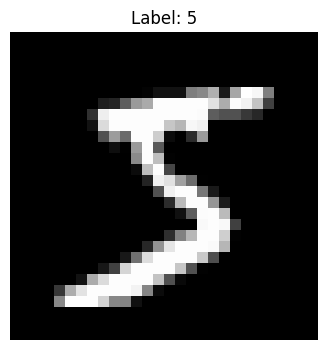

In [3]:
plt.figure(figsize=(4, 4))

plt.imshow(X_train[0], cmap="gray")

plt.title(f"Label: {y_train[0]}")

plt.axis("off")

plt.show()

In [4]:
print("Data type:", X_train.dtype)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [5]:
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0

print("X_train_norm dtype:", X_train_norm.dtype)
print("Minimum value:", X_train_norm.min())
print("Maximum value:", X_train_norm.max())

X_train_norm dtype: float32
Minimum value: 0.0
Maximum value: 1.0


In [6]:
X_train_flat = X_train_norm.reshape(60000, 784)
X_test_flat = X_test_norm.reshape(10000, 784)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (60000, 784)
X_test_flat shape: (10000, 784)


In [7]:
import torch

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


this is to define our architecture

In [8]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(784, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
)


this is to verify the count of total no of parametres , we calculated this in the notes

In [9]:
total_params = 0

for name, param in model.named_parameters():
    print(name, param.shape, param.numel())
    total_params += param.numel()

print("Total parameters:", total_params)

0.weight torch.Size([16, 784]) 12544
0.bias torch.Size([16]) 16
2.weight torch.Size([10, 16]) 160
2.bias torch.Size([10]) 10
Total parameters: 12730


this is just to check prediction before training the model

In [10]:
sample = torch.tensor(X_train_flat[0:1], dtype=torch.float32)

with torch.no_grad():
    output = model(sample)

print("True label:", y_train[0])
print("Model output:", output)
print("Predicted digit:", torch.argmax(output).item())

True label: 5
Model output: tensor([[ 0.1805,  0.0646, -0.1181, -0.0540,  0.1596, -0.1353, -0.1360, -0.0118,
         -0.1081,  0.0443]])
Predicted digit: 0


this is just to convert from NumPy data to PyTorch tensors

In [11]:
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([60000, 784])
y_train_tensor: torch.Size([60000])
X_test_tensor: torch.Size([10000, 784])
y_test_tensor: torch.Size([10000])


this is to configure the batch dividing

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 469
Number of test batches: 79


In [13]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", loss_function)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


we are running 10 times for the model to go throgh all 60k images and for each epoch the loss should decrease

In [14]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Calculate loss
        loss = loss_function(outputs, labels)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/10], Loss: 0.6808
Epoch [2/10], Loss: 0.2992
Epoch [3/10], Loss: 0.2624
Epoch [4/10], Loss: 0.2382
Epoch [5/10], Loss: 0.2201
Epoch [6/10], Loss: 0.2050
Epoch [7/10], Loss: 0.1930
Epoch [8/10], Loss: 0.1835
Epoch [9/10], Loss: 0.1754
Epoch [10/10], Loss: 0.1679


measuring the accuracy over testimages and trained images

In [15]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print("Correct predictions:", correct)
print("Total test images:", total)
print(f"Test accuracy: {accuracy:.2f}%")

Correct predictions: 9484
Total test images: 10000
Test accuracy: 94.84%


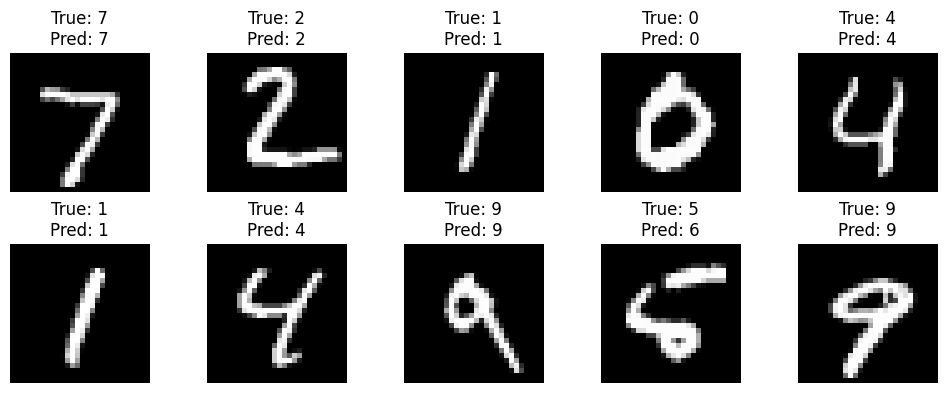

In [16]:
import matplotlib.pyplot as plt

model.eval()

plt.figure(figsize=(10, 4))

for i in range(10):

    image = X_test_tensor[i:i+1]

    with torch.no_grad():
        output = model(image)
        prediction = torch.argmax(output, dim=1).item()

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test[i]}\nPred: {prediction}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
total_params = 0
total_bytes = 0

print("Layer-wise parameter information")
print("-" * 60)

for name, param in model.named_parameters():

    num_params = param.numel()
    bytes_used = num_params * param.element_size()

    print(
        f"{name:10s} | "
        f"Shape: {str(tuple(param.shape)):15s} | "
        f"Parameters: {num_params:6d} | "
        f"Bytes: {bytes_used:6d} | "
        f"Type: {param.dtype}"
    )

    total_params += num_params
    total_bytes += bytes_used

print("-" * 60)
print("Total parameters:", total_params)
print("Total model bytes:", total_bytes)
print("Total model KiB:", total_bytes / 1024)
print("Total model KB:", total_bytes / 1000)

Layer-wise parameter information
------------------------------------------------------------
0.weight   | Shape: (16, 784)       | Parameters:  12544 | Bytes:  50176 | Type: torch.float32
0.bias     | Shape: (16,)           | Parameters:     16 | Bytes:     64 | Type: torch.float32
2.weight   | Shape: (10, 16)        | Parameters:    160 | Bytes:    640 | Type: torch.float32
2.bias     | Shape: (10,)           | Parameters:     10 | Bytes:     40 | Type: torch.float32
------------------------------------------------------------
Total parameters: 12730
Total model bytes: 50920
Total model KiB: 49.7265625
Total model KB: 50.92


a clean baseline record in Python.

In [18]:
baseline = {
    "architecture": "784-16-10",
    "activation": "ReLU",
    "parameters": 12730,
    "precision": "FP32",
    "model_memory_bytes": 50920,
    "model_memory_KiB": 50920 / 1024,
    "epochs": 10,
    "batch_size": 128,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "training_loss": 0.1679,
    "test_accuracy": 94.84
}

for key, value in baseline.items():
    print(f"{key}: {value}")

architecture: 784-16-10
activation: ReLU
parameters: 12730
precision: FP32
model_memory_bytes: 50920
model_memory_KiB: 49.7265625
epochs: 10
batch_size: 128
optimizer: Adam
learning_rate: 0.001
training_loss: 0.1679
test_accuracy: 94.84


this is just a fn to train , so that we can call this with other models

In [20]:
def train_model(hidden_size, num_epochs=10):

    # Create model
    model_test = nn.Sequential(
        nn.Linear(784, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 10)
    )

    # Loss and optimizer
    loss_function_test = nn.CrossEntropyLoss()

    optimizer_test = torch.optim.Adam(
        model_test.parameters(),
        lr=0.001
    )

    # Training
    for epoch in range(num_epochs):

        model_test.train()
        total_loss = 0

        for images, labels in train_loader:

            optimizer_test.zero_grad()

            outputs = model_test(images)

            loss = loss_function_test(outputs, labels)

            loss.backward()

            optimizer_test.step()

            total_loss += loss.item()

    # Testing
    model_test.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model_test(images)

            predictions = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total

    # Parameter count
    total_params = sum(
        p.numel() for p in model_test.parameters()
    )

    # Memory
    total_bytes = sum(
        p.numel() * p.element_size()
        for p in model_test.parameters()
    )

    return model_test, accuracy, total_params, total_bytes

this is for lower config than our baseline

In [21]:
model_8, acc_8, params_8, bytes_8 = train_model(8)

print("Model: 784-8-10")
print("Accuracy:", acc_8)
print("Parameters:", params_8)
print("Memory (bytes):", bytes_8)
print("Memory (KiB):", bytes_8 / 1024)

Model: 784-8-10
Accuracy: 92.57
Parameters: 6370
Memory (bytes): 25480
Memory (KiB): 24.8828125


In [22]:
model_32, acc_32, params_32, bytes_32 = train_model(32)

print("Model: 784-32-10")
print("Accuracy:", acc_32)
print("Parameters:", params_32)
print("Memory (bytes):", bytes_32)
print("Memory (KiB):", bytes_32 / 1024)

Model: 784-32-10
Accuracy: 96.1
Parameters: 25450
Memory (bytes): 101800
Memory (KiB): 99.4140625


In [23]:
model_64, acc_64, params_64, bytes_64 = train_model(64)

print("Model: 784-64-10")
print("Accuracy:", acc_64)
print("Parameters:", params_64)
print("Memory (bytes):", bytes_64)
print("Memory (KiB):", bytes_64 / 1024)

Model: 784-64-10
Accuracy: 97.3
Parameters: 50890
Memory (bytes): 203560
Memory (KiB): 198.7890625


In [24]:
model_128, acc_128, params_128, bytes_128 = train_model(128)

print("Model: 784-128-10")
print("Accuracy:", acc_128)
print("Parameters:", params_128)
print("Memory (bytes):", bytes_128)
print("Memory (KiB):", bytes_128 / 1024)

Model: 784-128-10
Accuracy: 97.78
Parameters: 101770
Memory (bytes): 407080
Memory (KiB): 397.5390625


In [25]:
model_256, acc_256, params_256, bytes_256 = train_model(256)

print("Model: 784-256-10")
print("Accuracy:", acc_256)
print("Parameters:", params_256)
print("Memory (bytes):", bytes_256)
print("Memory (KiB):", bytes_256 / 1024)

Model: 784-256-10
Accuracy: 97.62
Parameters: 203530
Memory (bytes): 814120
Memory (KiB): 795.0390625


In [26]:
# Select our final model
final_model = model_128

# Count parameters
total_params = sum(p.numel() for p in final_model.parameters())

# Float32 memory
float32_bytes = total_params * 4

print("Final model: 784-128-10")
print("Accuracy:", acc_128)
print("Parameters:", total_params)
print("Float32 memory:", float32_bytes, "bytes")
print("Float32 memory:", float32_bytes / 1024, "KiB")

Final model: 784-128-10
Accuracy: 97.78
Parameters: 101770
Float32 memory: 407080 bytes
Float32 memory: 397.5390625 KiB


In [27]:
# Check the final model's parameter types

for name, param in final_model.named_parameters():
    print(name, param.dtype)

0.weight torch.float32
0.bias torch.float32
2.weight torch.float32
2.bias torch.float32
